In [ ]:
import os, io
from PIL import Image
from IPython.display import display

In [ ]:
from google.colab import userdata

os.environ['GOOGLE_API_KEY'] = userdata.get('GOOGLE_API_KEY')
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')

# Gemini Image Generation Models

In [ ]:
from google import genai
from google.genai import types
from PIL import Image

client = genai.Client()

## Nano Banana

In [ ]:
prompt = ('Present a clear, 45° top-down isometric miniature 3D cartoon scene of London, featuring its most iconic landmarks and architectural elements. Use soft, refined textures with realistic PBR materials and gentle, lifelike lighting and shadows. Integrate the current weather conditions directly into the city environment to create an immersive atmospheric mood. Use a clean, minimalistic composition with a soft, solid-colored background. At the top-center, place the title "London" in large bold text, a prominent weather icon beneath it, then the date (small text) and temperature (medium text). All text must be centered with consistent spacing, and may subtly overlap the tops of the buildings.')
response = client.models.generate_content(
    model="gemini-3.1-flash-image-preview",
    contents=[prompt],
)

In [ ]:
for part in response.parts:
    if part.text is not None:
        print(part.text)
    elif part.inline_data is not None:
        image = part.as_image()
        image.save("generated_image.png")
        image.show()

Output hidden; open in https://colab.research.google.com to view.

## Imagen

In [ ]:
response = client.models.generate_images(
    model='imagen-4.0-generate-001',
    prompt='a street view of main street in a big city',
    config=types.GenerateImagesConfig(
        number_of_images= 1,
        aspectRatio="16:9"
    )
)

In [ ]:
for generated_image in response.generated_images:
  generated_image.image.show()

Output hidden; open in https://colab.research.google.com to view.

## Grounding with Google Search

In [ ]:
prompt = "Visualize the current weather forecast for the next 5 days in Jakarta as a clean, modern weather chart. Add a visual on what I should wear each day"

response = client.models.generate_content(
    model="gemini-3.1-flash-image-preview",
    contents=prompt,
    config=types.GenerateContentConfig( response_modalities=['Text', 'Image'], tools=[{"google_search": {}}])
)

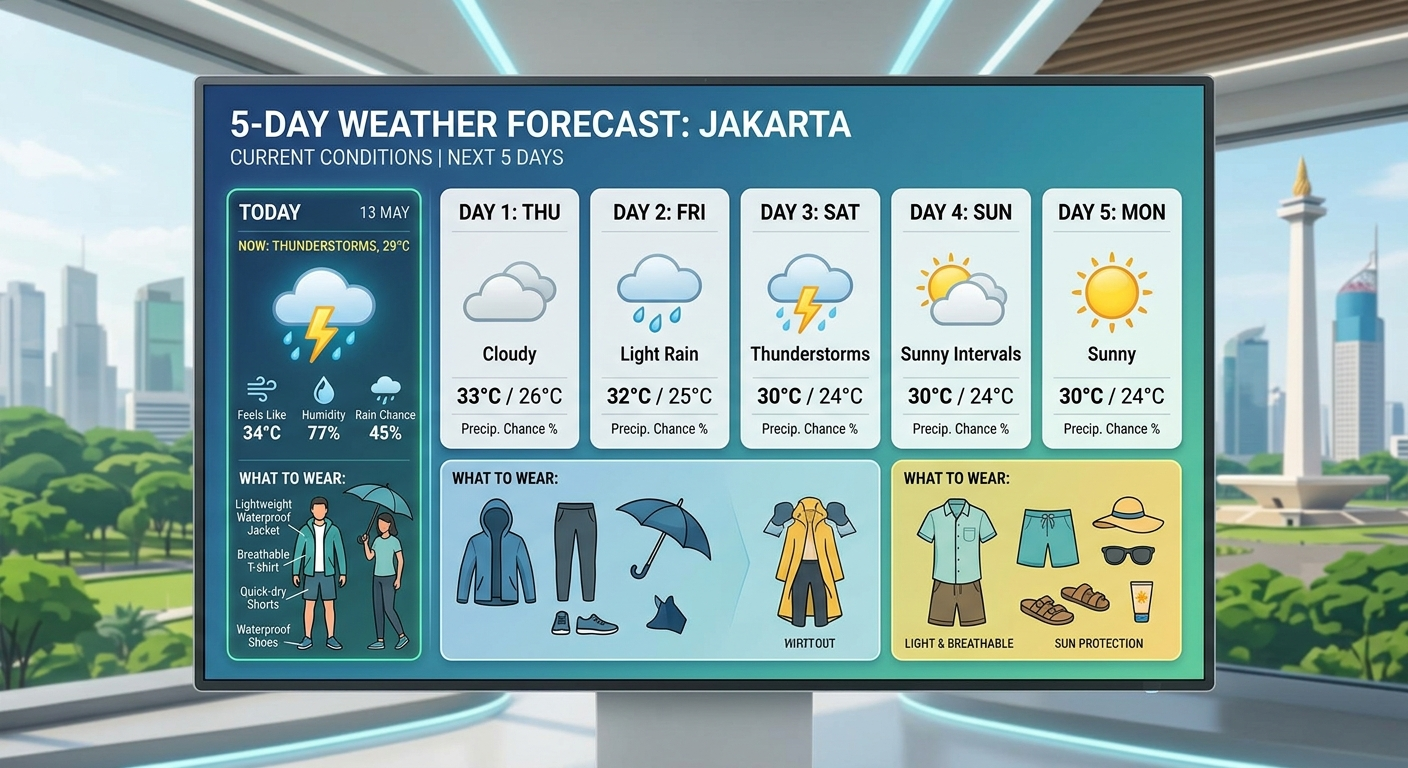

In [ ]:
for part in response.parts:
    if part.text is not None:
        print(part.text)
    elif image:= part.as_image():
        image.save("weather.png")
        image.show()

# OpenAI Image Generation Model

In [11]:
from openai import OpenAI
import base64
client = OpenAI()

## GPT Image 2

In [12]:
prompt = """
A children's book drawing of a veterinarian using a stethoscope to
listen to the heartbeat of a baby otter.
"""

result = client.images.generate(
    model="gpt-image-2",
    prompt=prompt,
    quality="low"
)

In [13]:
image_base64 = result.data[0].b64_json
image_bytes = base64.b64decode(image_base64)

with open("otter.png", "wb") as f:
    f.write(image_bytes)

image = Image.open(io.BytesIO(image_bytes))
display(image)

Output hidden; open in https://colab.research.google.com to view.

## GPT Image 1.5

In [14]:
prompt = """
Edit the perfume product photo by adding a refined label and brand details to the existing bottle. Preserve the bottle shape, lighting, marble plinth, petals, reflections, and luxury print-ad composition. Logo: a thin gold monogram shaped like a neural network growing into a jasmine vine, centered near the top of the label. Text on the label, rendered cleanly and exactly: "EAU DE A.G.I." "JASMINE INTELLIGENCE" "50 ml" Use elegant high-contrast serif typography with small gold accents and a cream label stock. Keep the result plausible as real product photography; no extra text, no watermark.
"""

result = client.images.generate(
    model="gpt-image-1.5",
    prompt=prompt,
    quality="low"
)

In [15]:
image_base64 = result.data[0].b64_json
image_bytes = base64.b64decode(image_base64)

with open("img.png", "wb") as f:
    f.write(image_bytes)

image = Image.open(io.BytesIO(image_bytes))
display(image)

Output hidden; open in https://colab.research.google.com to view.